In [56]:
import sys

print(sys.version)
print('Colab')

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Colab


In [57]:
!nvidia-smi

Fri Jul 31 02:05:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             35W /   70W |     241MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# MNIST 손글씨 숫자 다중 클래스 분류
- 0 ~ 9 손글씨 이미지 (해상도 28x28)

### 학습 목표
- CNN 기반 이미지 분류 모델 (이미지 특징 추출에 특화된 모델)
- train / valid / test 데이터 분리
- 데이터 정규화 및 데이터 증강(입력 이미지를 조금씩 변형하여 일반화 성능 향상)
- DataLoader를 활용하여 미니배치 학습
- CrossEntropyLoss 손실함수
- AdamW 최적화함수(Adam + Weight Decay)
- Scheduler (학습 상황에 따라 learning rate 조정)
- BatchNorm (학습 안정화, 학습 수렴 지원), Dropout(일부 랜덤 뉴런 비활성화. 과적합 방지), Weight Decay (특정 가중치가 너무 커지는 것을 방지. 과적합 방지)
- Gradient Clipping (기울기가 너무 커지는 문제 완화)
- EalryStopping (일정 학습기간동안 성능 개선 없을시 조기종료)
- 시각화
- Confusion Matrix 등 지표
- 오분류 이미지 확인

### 기본 정보
- 문제유형 : 다중 클래스 분류
- 입력 데이터 : 28x28 흑백 손글씨 이미지
- 출력 데이터 : 숫자 클래스 0~9

1. 라이브러리 불러오기

In [58]:
import random         # 시드 고정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn         # 신경망 구성
import torch.optim as optim   # 최적화 함수
from torch.utils.data import DataLoader, Subset  # 미니배치 / 데이터 분리

from torchvision import datasets, transforms  # 이미지 데이터셋 / 이미지 전처리 도구

from tqdm.auto import tqdm  # 진행바

# 지표 관련
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 한글 폰트 설정 (Mac은 AppleGothic)
# plt.rcParams["font.family"] = "Malgun Gothic"

# # 마이너스 기호 깨짐 방지
# plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# Colab 환경 (linux)에서 폰트 다운받고 한글패치
!apt-get update -qq
!apt-get install -qq fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont(
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


2. 랜덤 시드 고정

In [60]:
SEED = 42

random.seed(SEED)                # Python random 시드 고정
np.random.seed(SEED)             # Numpy 시드 고정
torch.manual_seed(SEED)          # Pytorch CPU 시드 고정
torch.cuda.manual_seed_all(SEED) # Pytorch GPU 시드 고정

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu') # GPU 사용가능시 GPU 사용(cuda), 아니면 CPU 사용(cpu)
device

device(type='cuda')

3. MNIST 데이터 불러오기

In [89]:
# MNIST에서 주로 정규화 전처리시에 사용하는 평균과 표준편차
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

# 학습 데이터 전처리 도구: 데이터 증강 + Tensor 변환 + 정규화
train_transform = transforms.Compose([
    transforms.RandomRotation(10),  # 이미지를 -10 ~ 10도 범위로 랜덤 회전
    transforms.ToTensor(),          # 이미지 내부값을 Tensor로 변환 (0~1 범위로 MinMax Scaling)
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))  # 평균과 표준편차를 이용해 정규화
])

# 검증 / 테스트 데이터 전처리 도구: Tensor 변환 + 정규화 (검증 / 테스트 시에는 증강 전처리는 사용안함)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))
])

# 학습용 MNIST 데이터셋 (증강 적용)
full_train_dataset_aug = datasets.MNIST(
    root = './data',    # 저장 경로
    train = True,       # 학습 / 테스트 데이터셋 중 학습 데이터셋
    download = True,    # 데이터 없으면 다운로드
    transform = train_transform  # 전처리 적용
)

# 검증용으로 사용할 학습 데이터셋 (증강 미적용)
full_train_dataset_eval = datasets.MNIST(
    root = './data',
    train = True,
    download = True,
    transform = eval_transform
)

# 최종 평가용 테스트 데이터셋 (증강 미적용)
test_dataset = datasets.MNIST(
    root = './data',
    train = False,      # 학습 / 테스트 데이터셋 중 테스트 데이터셋
    download = True,
    transform = eval_transform
)

print(f"전체 학습 데이터 수 : {len(full_train_dataset_aug)}")
print(f"전체 검증 데이터 수 : {len(full_train_dataset_eval)}")
print(f"테스트 데이터 수 : {len(test_dataset)}")

전체 학습 데이터 수 : 60000
전체 검증 데이터 수 : 60000
테스트 데이터 수 : 10000


In [62]:
full_train_dataset_aug[0]  # 첫번째 학습 데이터의 데이터와 정답

(tensor([[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.424

4. Train / Valid 데이터 분리
- train 데이터 : 모델 가중치 학습용
- valid 데이터 : 성능 확인 및 EarlyStopping 판단, Scheduler
- test 데이터 : 학습 종료 후 최종 성능 평가

In [63]:
valid_size = 10_000
train_size = len(full_train_dataset_aug) - valid_size

generator = torch.Generator().manual_seed(SEED)  # 데이터 분리시 재현성 추가를 위한 generator 객체
# 전체 인덱스 섞어 인덱스 반환(한번 사용한 인덱스는 다시 나오지 않음)
indices = torch.randperm(len(full_train_dataset_aug), generator=generator)

train_indices = indices[:train_size]  # 학습용 인덱스
valid_indices = indices[train_size:]  # 검증용 인덱스

train_dataset = Subset(full_train_dataset_aug, train_indices)    # 데이터 분리(데이터, 인덱스). 증강 적용한 학습 데이터셋
valid_dataset = Subset(full_train_dataset_eval, valid_indices)   # 증강 없는 검증 데이터셋

print(f"학습 데이터 수 : {len(train_dataset)}, 검증 데이터 수 : {len(valid_dataset)}, 테스트 데이터 수 : {len(test_dataset)}")

학습 데이터 수 : 50000, 검증 데이터 수 : 10000, 테스트 데이터 수 : 10000


5. 클래스 분포 확인

In [64]:
full_train_dataset_eval.targets[train_indices].numpy()

array([6, 7, 6, ..., 4, 4, 0])

In [65]:
test_dataset.targets

tensor([7, 2, 1,  ..., 4, 5, 6])

In [66]:
class_names = [str(i) for i in range(10)]

train_labels = full_train_dataset_eval.targets[train_indices].numpy()  # train label
valid_labels = full_train_dataset_eval.targets[valid_indices].numpy()  # valid label
test_labels = test_dataset.targets.numpy()  # test label

label_df = pd.DataFrame({
    "train" : pd.Series(train_labels).value_counts().sort_index(),  # train class 갯수
    "valid" : pd.Series(valid_labels).value_counts().sort_index(),  # valid class 갯수
    "test" : pd.Series(test_labels).value_counts().sort_index(),    # test class 갯수
})

label_df

,train,valid,test
0,4923,1000,980
1,5613,1129,1135
2,4958,1000,1032
3,5093,1038,1010
4,4863,979,982
5,4546,875,892
6,4933,985,958
7,5204,1061,1028
8,4882,969,974
9,4985,964,1009


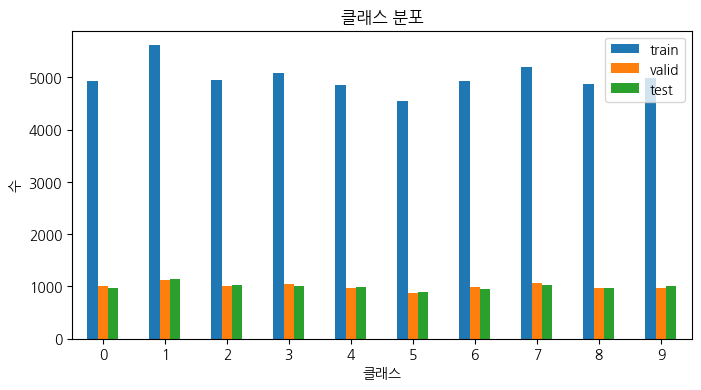

In [67]:
label_df.plot(kind='bar', figsize=(8, 4))
plt.title("클래스 분포")
plt.xlabel("클래스")
plt.ylabel("수")
plt.xticks(rotation=0)
plt.show()

### 6. DataLoader 생성하여 미니배치 학습

In [68]:
import os

os.cpu_count()

2

In [69]:
BATCH_SIZE = 128            # 이미지 128장씩 사용

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle= True,          # epoch마다 섞음
    num_workers= 0          # 병렬처리 코어 (0은 메인코어)
)
valid_loader = DataLoader(
    valid_dataset,          
    batch_size = BATCH_SIZE,
    shuffle= False,
    num_workers= 0
)
test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle= False,
    num_workers= 0
)


images, labels = next(iter(train_loader))

print(f"image_size : {images.shape} , laber_size : {labels.shape}") # (batch_size ,channel,height,width), (batch_size)
# print(images.shape)
# print(labels.shape)

image_size : torch.Size([128, 1, 28, 28]) , laber_size : torch.Size([128])


### 7. 이미지 데이터 확인

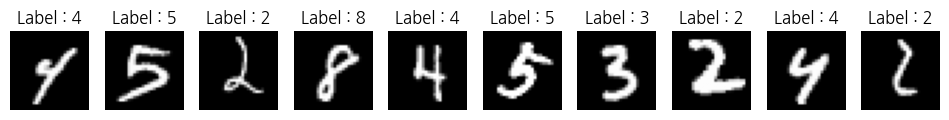

In [70]:
# 역전규화 함수 : 시각화해서 표현하기 위해 원래 범위에 가깝게 되돌리는 함수

def denormalize(image_tensor):
    return image_tensor * MNIST_MEAN + MNIST_MEAN

# 이미지 확인 함수
def show_images(dataset, n= 10):
    plt.figure(figsize = (12,2))

    for i in range(n):
        image, label = dataset[i]
        # 흑백 이미지는 차원이 1일 경우 삭제
        # (컬러 이미지는 삭제하지 않음. imshow[ 높이,너비,채널 ] 순으로 맞춰 사용. permute 함수로 차원 순서 변경
        image = denormalize(image).squeeze(0)

        plt.subplot(1, n, i + 1)            # subplot 위치 지정
        plt.imshow(image, cmap ='gray')     # 흑백 이미지 출력
        plt.title(f"Label : {label}")
        plt.axis('off')     # 축 제거

    plt.show()
    
show_images(valid_dataset,10)

### 8. CNN 기반 이미지 분류모델

In [71]:
# MNISTCNN 손글씨 이미지를 0~9 중 하나로 분류하는 모델

class MNISTCNN(nn.Module):

    def __init__(self,dropout_rate = 0.25):
        super().__init__()

        # 이미지에서 특징을 추출하는 부분
        self.features = nn.Sequential(
            nn.Conv2d(1,16,kernel_size=3, padding=1),   # 흑백 이미지 1채널 -> 특징맵 16개 생성
            nn.BatchNorm2d(16), # 16개 채널값 정규화
            nn.SiLU(),          # 비선형 추가
            nn.MaxPool2d(kernel_size=2),    # 이미지 크기를 절반으로 축소 (28 X 28 -> 14 X 14)
            nn.Dropout2d(dropout_rate),     # 랜덤 특징맵 비활성화 (과적합 완화)

            nn.Conv2d(16,32,kernel_size=3, padding=1),  # 특징 맵 16 -> 32개 확장 (다양한 특징 추출)
            nn.BatchNorm2d(32), 
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),    # 이미지 크기를 절반으로 축소 (14 X 14 -> 7 X 7)
            nn.Dropout2d(dropout_rate)      
        )

        # 추출된 특징을 바탕으로 최종 클래스 분류하는 분류기
        self.classifier = nn.Sequential(
            nn.Flatten(),               # 3차원의 특징맵을 1차원 벡터로 변환 : 32 * 7 * -> 1_568
            nn.Linear(32*7*7,128),      # 1568개의 특징 벡터를 128개의 은닉 노드로 변환
            nn.BatchNorm1d(128),        # 출력 정규화
            nn.SiLU(),                  # 비선형 추가
            nn.Dropout(0.4),            # 일부 뉴런 비활성화 (과적합 완화)
            nn.Linear(128,10)           # 출력 : 숫자 0~9의 10개 클래스 점수
        )

    def forward(self,x):
        x = self.features(x)    # 특징 추출
        x = self.classifier(x)  # 클래스별 점수 계산
        return x                # softmax 함수 적용 전 logits

model = MNISTCNN().to(device)
model

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): SiLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): SiLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

### 9. 손실함수, 최적화 함수, Scheduler 설정
- CrossEntropy 손실함수 : 모델 출력값을 내부적으로 확률로 처리하여, 모델의 출력부분에 Softmax를 따로 붙이지 않아도 된다.


In [72]:
# 다중 클래스 분류용 손실함수(label_smoothing(5% 정답 미확신))

criterion = nn.CrossEntropyLoss(label_smoothing= 0.05)

optimizer = optim.AdamW(
    model.parameters(),     # 학습할 모델 파라미터
    lr = 0.001,             # 학습률
    weight_decay= 1e-4,     # L2 규제 슈치 (과적합 완화)

)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',   # valid_loss 기준이라 감소하는 방향
    factor= 0.5,    # learning rate 감소율
    patience = 2    # 2 epoch 동안 개선 없으면 조정
)

### 10. EarlyStopping 클래스 정의
- 일정 epoch동안 개선이 없으면 학습 조기종료

In [73]:
class EarlyStopping:

    def __init__(self, patience =4, min_delta = 0.0):
        self.patience = patience        # 개선을 기다릴 epoch
        self.min_delta = min_delta      # 개선으로 인정할 최소 변화량
        self.best_loss = float('inf')   # 최소 valid loss
        self.counter = 0                # 개선이 없었던 epoch
        self.best_state = None          # 최고 성능 모델 가중치


    def __call__(self, valid_loss, model):
        # valid loss가 원하는 만큼 개선이 된 경우
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0
            self.best_state ={
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            return False
        self.counter+=1 
        return self.counter >= self.patience

    # 가장 성능이 좋은 모델의 가중치를 모델에 복원
    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


### 11. 학습함수와 평가 함수 정의

In [74]:
# 모델을 1epoch 학습하는 함수

def train_one_epoch(model, dataloader, criterion, optimizer, device, max_norm = 1.0): 
    model.train()   # 학습 모드

    total_loss = 0.0    # 전체 손실 (평균 계산)
    total_correct = 0   # 맞춘 갯수 (정확도 계산)
    total_count = 0     # 총 갯수(평균,정확도 계산)

    for images, labels in tqdm(dataloader, desc = 'Train', leave= False):   # 진행바 남기지않음
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()   # 이전 step 기울기 초기화
    
        outputs = model(images)  # 예측 logits 반환
        loss = criterion(outputs,labels) # 손실 계산 (내부에서 softmax로 확률 변환)

        loss.backward()     # 기울기 계산
        # Gridient Clipping : 특정 기울기 폭주 방지 (규제) -> 과적합 방 
        torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=max_norm)    
        optimizer.step()    # 가중치 업데이트

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        # 클래스별 점수 중 가장 큰값의 인덱스가 정답이랑 같은 것(예측 성공)의 갯수를 python숫자형태로 누
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_count += batch_size

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count

    return avg_loss, avg_acc        

In [75]:
# 평가하는 함수

def evaluate(model, dataloader,criterion,device):
    model.eval()    # 평가 모드

    total_loss = 0.0    # 전체 손실 (평균 계산)
    total_correct = 0   # 맞춘 갯수 (정확도 계산)
    total_count = 0     # 총 갯수(평균,정확도 계산)

    
    with torch.no_grad():   # 평가 중에 기울기 계산 비활성화
        for images, labels in tqdm(dataloader, desc = 'Train', leave= False):   # 진행바 남기지않음
                images = images.to(device)
                labels = labels.to(device)
        
            
                outputs = model(images)  # 예측 logits 반환
                loss = criterion(outputs,labels) # 손실 계산 (내부에서 softmax로 확률 변환)

        
                batch_size = images.size(0)
                total_loss += loss.item() * batch_size
                # 클래스별 점수 중 가장 큰값의 인덱스가 정답이랑 같은 것(예측 성공)의 갯수를 python숫자형태로 누
                total_correct += (outputs.argmax(dim=1) == labels).sum().item()
                total_count += batch_size

    avg_loss = total_loss / total_count     # epoch 전체 평균 손실
    avg_acc = total_correct / total_count   # epoch 전체 정확도

    return avg_loss, avg_acc       



### 12. 모델 학습

In [76]:
EPOCHS = 10
early_stopping = EarlyStopping(patience= 4, min_delta= 0.0001)
history = []

for epoch in tqdm(range(EPOCHS),desc= 'Epoch'):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate(model, valid_loader,criterion,device)

    scheduler.step(valid_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history.append({
        'epoch' : epoch+1,
        'train_loss': train_loss,
        'train_acc' : train_acc,
        'valid_loss': valid_loss,
        'valid_acc' : valid_acc,
        'lr' : current_lr
    })

    print(
        f"Epoch : {epoch+1} | "
        f"Train Loss : {train_loss:.4f} | Train ACC : {train_acc:.4f} |"
        f"Valid Loss : {valid_loss:.4f} | Valid ACC : {valid_acc:.4f} |"
        f"Learning Rate : {current_lr:.6f} |"
    )

    if early_stopping(valid_loss,model):
        print("검증 손실 개선이 이루어 지지않아 EarlyStopping 작동!")
        break

early_stopping.restore_best_weights(model)


Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Train:   0%|          | 0/391 [00:00<?, ?it/s]

Train:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch : 1 | Train Loss : 0.5724 | Train ACC : 0.9229 |Valid Loss : 0.3869 | Valid ACC : 0.9800 |Learning Rate : 0.001000 |


Train:   0%|          | 0/391 [00:00<?, ?it/s]

...

Train:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch : 9 | Train Loss : 0.3832 | Train ACC : 0.9829 |Valid Loss : 0.3477 | Valid ACC : 0.9891 |Learning Rate : 0.001000 |


Train:   0%|          | 0/391 [00:00<?, ?it/s]

Train:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch : 10 | Train Loss : 0.3826 | Train ACC : 0.9818 |Valid Loss : 0.3455 | Valid ACC : 0.9900 |Learning Rate : 0.001000 |


In [77]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,0.572400,0.92288,0.386855,0.9800,0.001
1,2,0.441813,0.96360,0.373083,0.9832,0.001
2,3,0.422231,0.97040,0.369403,0.9847,0.001
3,4,0.408899,0.97500,0.364377,0.9864,0.001
4,5,0.399446,0.97786,0.356908,0.9879,0.001
5,6,0.394814,0.97934,0.352442,0.9883,0.001
6,7,0.390421,0.98008,0.352429,0.9879,0.001
7,8,0.386226,0.98096,0.350154,0.9883,0.001
8,9,0.383176,0.98290,0.347670,0.9891,0.001
9,10,0.382563,0.98182,0.345542,0.9900,0.001


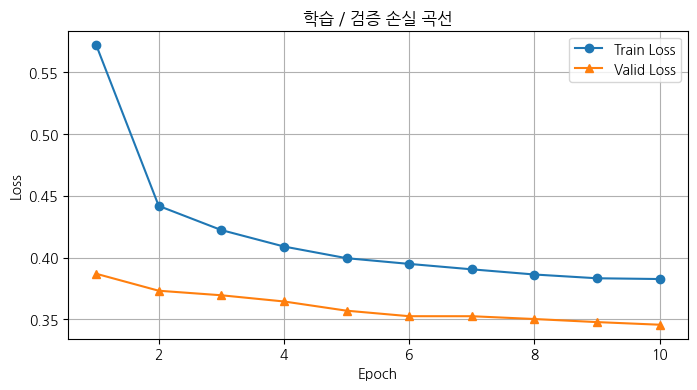

In [78]:
# Train and Validation Loss

plt.figure(figsize = (8,4))
plt.plot(history_df['epoch'], history_df['train_loss'], marker = 'o', label = 'Train Loss')
plt.plot(history_df['epoch'], history_df['valid_loss'], marker = '^', label = 'Valid Loss')
plt.title('학습 / 검증 손실 곡선')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

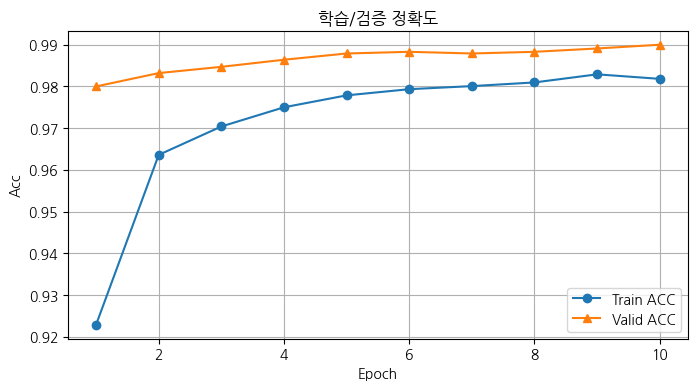

In [79]:
# Train and Validation 정확도 곡선

plt.figure(figsize = (8,4))
plt.plot(history_df['epoch'], history_df['train_acc'], marker = 'o', label = 'Train ACC')
plt.plot(history_df['epoch'], history_df['valid_acc'], marker = '^', label = 'Valid ACC')
plt.title('학습/검증 정확도')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.legend()
plt.grid(True)
plt.show()

### 14. Test 데이터로 최종 평가

In [80]:
test_loss , test_acc = evaluate(model, test_loader ,criterion,device)

print(f"Test Loss : {test_loss}, Test Accuracy : {test_acc}")

Train:   0%|          | 0/79 [00:00<?, ?it/s]

Test Loss : 0.34115336618423464, Test Accuracy : 0.9908


### 15. 예측 결과 수집 & 시각화

In [81]:
def get_predictions(model, dataloader, device):
    model.eval()    # 평가 모드

    y_true = []     # 실제 정답
    y_pred = []     # 예측 클래스
    y_prob = []     # 예측 확률

    
    with torch.no_grad():   # 평가 중에 기울기 계산 비활성화
        for images, labels in tqdm(dataloader, desc = 'Get Predictions',leave= False):  
                images = images.to(device)

                outputs = model(images)  # 예측 logits 반환
                predictions = outputs.argmax(dim=1) # 클래스 별 가장 높은 점수 클래스를 예측값으로 선택
                probabilities = torch.softmax(outputs, dim=1 )  # logits을 클래스별 확률로 변환

                y_true.append(labels.cpu().numpy())         # 실제 정답 numpy배열 형태로 저장
                y_pred.append(predictions.cpu().numpy())    # 예측 클래스도 CPU 이동 후 numpy 형태 저장
                y_prob.append(probabilities.cpu().numpy())  # 예측 확률도 CPU 이동 후 numpy 형태 저장


    return np.concatenate(y_true),np.concatenate(y_pred),np.concatenate(y_prob) # 배치별 값을 하나의 배열 형태로 합침
        

y_true,y_pred,y_prob = get_predictions(model, test_loader, device)

print(y_true[:20])
print(y_pred[:20])

Get Predictions:   0%|          | 0/79 [00:00<?, ?it/s]

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [82]:
print(f"Test Accuracy : {accuracy_score(y_true,y_pred)}")
print(f"{classification_report(y_true,y_pred,target_names=class_names)}")

Test Accuracy : 0.9908
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### 16. Confusion Matrix

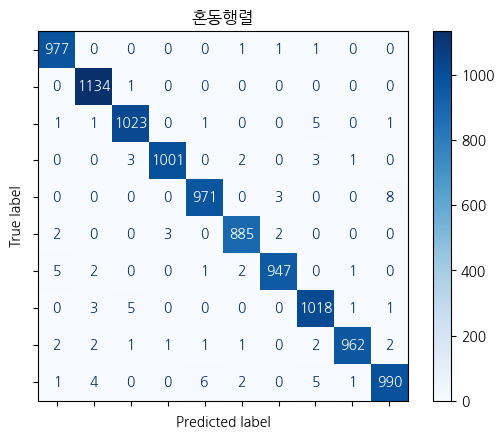

In [83]:
cm = confusion_matrix(y_true, y_pred) # 혼동 행렬 계싼

disp = ConfusionMatrixDisplay(
    confusion_matrix= cm,
    display_labels=[]

)

disp.plot(cmap = 'Blues', values_format='d')
plt.title('혼동행렬')
plt.show()

### 17. 예측 결과 이미지 확인

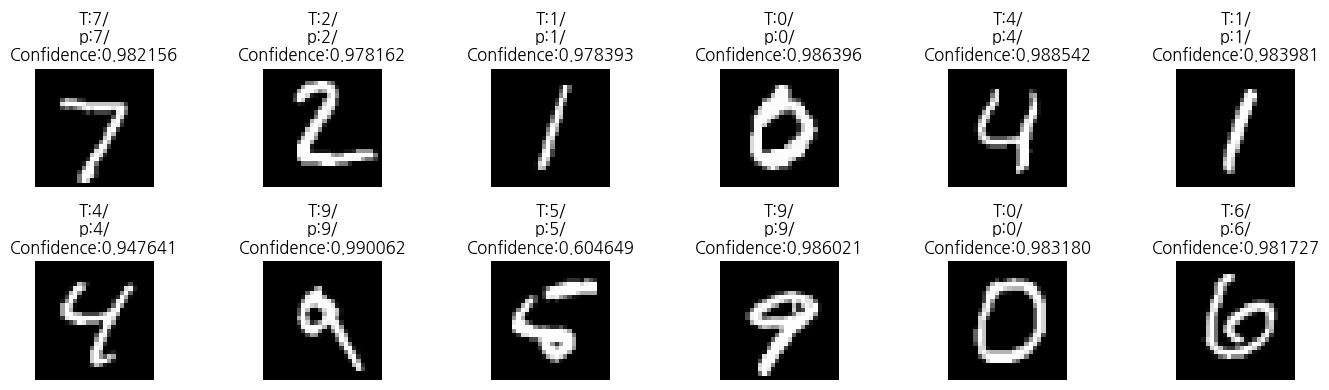

In [84]:
# 테스트 이미지와 예측 결과를 출력하는 함수
def show_predictions(dataset, y_pred, y_prob, n=12):
    plt.figure(figsize = (14,4))

    for i in range(n):
        image, label = dataset[i]
        image_for_plot = denormalize(image).squeeze(0)  # 역전규화 및 채널 차원제거

        pred_label = y_pred[i]
        confidence = y_prob[i, pred_label]

        plt.subplot(2,6,i+1)
        plt.imshow(image_for_plot ,cmap='gray') # 흑백 이미지 출력
        plt.title(f"T:{label}/\np:{pred_label}/\nConfidence:{confidence:3f}")
        plt.axis('off')

    plt.tight_layout()  # 레이아웃 자동조정
    plt.show()

show_predictions(test_dataset,y_pred,y_prob)


### 18. 오분류 이미지 확인

In [85]:
wrong_indices = np.where(y_true != y_pred)[0]
len(wrong_indices)

92

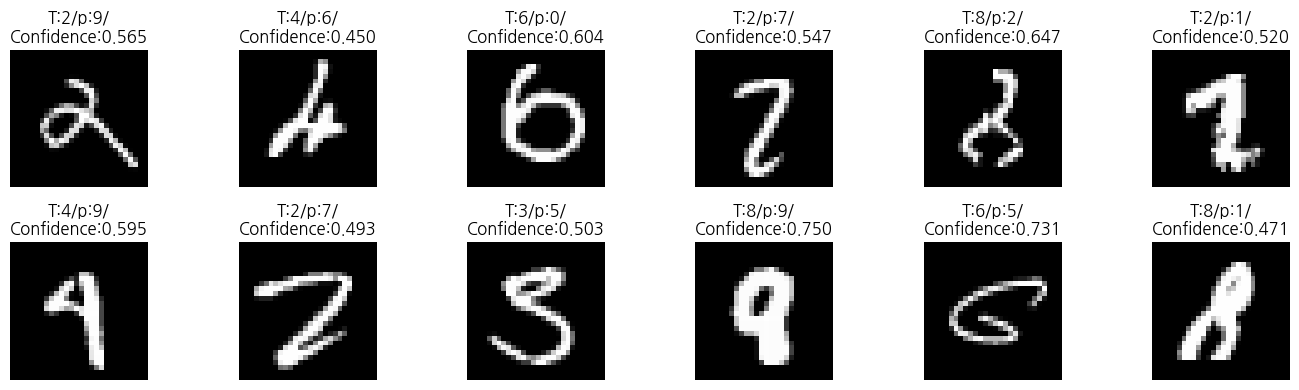

In [86]:
# 오분류 이미지 출력 함수

def show_predictions(dataset, wrong_indices,y_pred, y_prob, n=12):
    if len(wrong_indices) ==0:
        print('오분류 이미지 없음')
        return

    n = min(n, len(wrong_indices))

    plt.figure(figsize = (14,4))

    for plot_idx in range(n):
        data_idx = wrong_indices[plot_idx]
        image, label = dataset[data_idx]
        image_for_plot = denormalize(image).squeeze(0)  # 역전규화 및 채널 차원제거

        pred_label = y_pred[data_idx]
        confidence = y_prob[data_idx, pred_label]

        plt.subplot(2,6, plot_idx + 1)
        plt.imshow(image_for_plot ,cmap='gray') # 흑백 이미지 출력
        plt.title(f"T:{label}/p:{pred_label}/\nConfidence:{confidence:.3f}")
        plt.axis('off')

    plt.tight_layout()  # 레이아웃 자동조정
    plt.show()


show_predictions(test_dataset, wrong_indices, y_pred, y_prob)

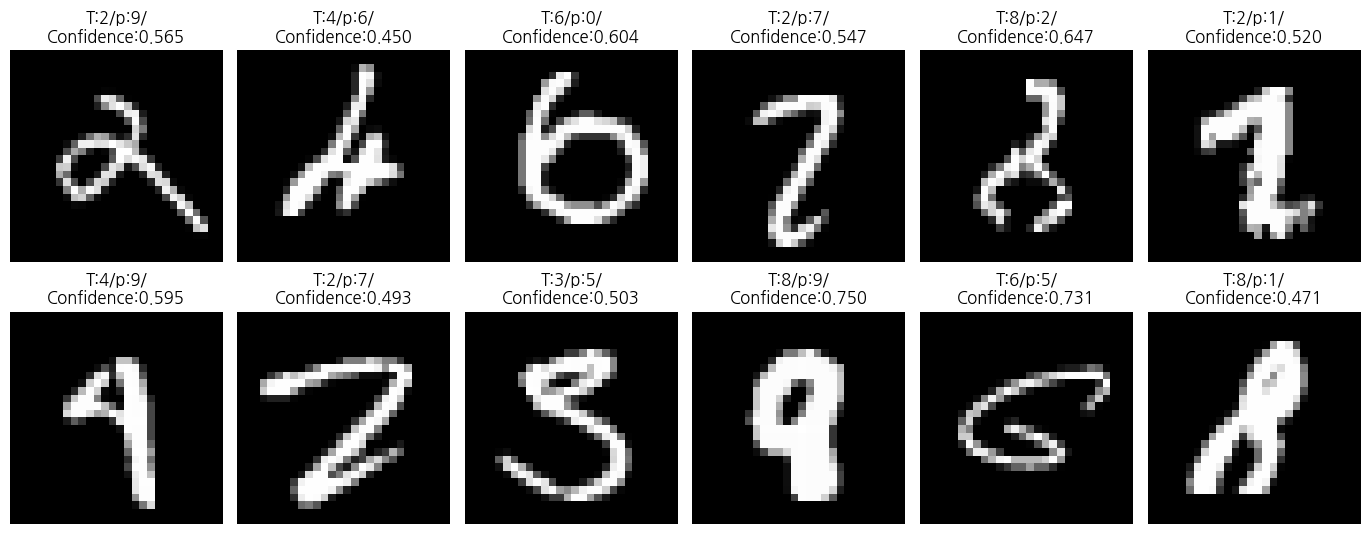

In [87]:
# 오분류 이미지 출력 함수

def show_predictions_active(dataset, wrong_indices,y_pred, y_prob, n=12):

    # 오분류 이미지 없을시 함수 종
    if len(wrong_indices) ==0:
        print('오분류 이미지 없음')
        return

    n = min(n, len(wrong_indices))  # 요청 개수, 못 맞춘 개수중 최소값

    cols = min(6, n)                # 한 줄에 최대 6개까지만 출력
    rows = int(np.ceil(n / cols))   # 필요한 행 개수

    fig, axes = plt.subplots(   
        rows,
        cols,
        figsize = (cols *2.3,rows *2.8)
    )

    axes = np.array(axes).reshape(-1)   # 1차원 배열로 변환(반복문 안에서 사용하기 위해)
    
    for plot_idx in range(n):
        data_idx = wrong_indices[plot_idx]  # 오분류한 데이터의 인덱스
        image, label = dataset[data_idx]
        image_for_plot = denormalize(image).squeeze(0).cpu().numpy()  # 역전규화 및 채널차원 제거(시각화용 numpy 변환)

        pred_label = y_pred[data_idx]
        confidence = y_prob[data_idx, pred_label]

        axes[plot_idx].imshow(image_for_plot, cmap= 'gray')
        axes[plot_idx].set_title(f"T:{label}/p:{pred_label}/\nConfidence:{confidence:.3f}")
        axes[plot_idx].axis('off')

    # n부터 나머지 데이터가 없는 subplots 부분 제거
    for empty_idx in range(n, len(axes)):
        axes[empty_idx.axis('off')] # 숨김처리

    plt.tight_layout()  # 레이아웃 자동조정
    plt.show()


show_predictions_active(test_dataset, wrong_indices, y_pred, y_prob)

### 19. 단일 이미지 예측 함수

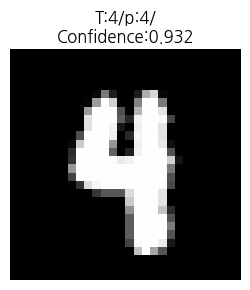

(4, 0.9323685169219971)

In [88]:
# 데이터셋에서 인덱스 이미지를 선택해서 예측하는 함수
def predict_one_image(model, dataset, index, device):
    model.eval()

    image, true_label = dataset[index]
    # batch 차원 추가해서 X데이터처럼 만듬(C,H,W) -> (B,C,H,W)
    input_image = image.unsqueeze(0).to(device) 

    with torch.no_grad():   # 평가 중에 기울기 계산 비활성화
        outputs = model(input_image)                    # 예측 logit 반환
        probabilities = torch.softmax(outputs, dim=1 )  # 클래스별 확률  
        pred_label = probabilities.argmax(dim=1).item() # 예측 클래스
        confidence = probabilities[0,pred_label].item() # 예측 확률 추출

    plt.figure(figsize = (3,3))
    # 역정규화 / 채널 차원제거해서 흑백 이미지 출력
    plt.imshow(denormalize(image).squeeze(0), cmap = 'gray')    
    plt.title(f"T:{true_label}/p:{pred_label}/\nConfidence:{confidence:.3f}")
    plt.axis('off')
    plt.show()
    
    
    return pred_label,confidence

predict_one_image(model, test_dataset, index=250, device= device)

고도화 기법
- Dropout 수정 / 제거
- Weight Decay 수정 / 제거
- Data Aumentation 여러 기법 도입 / 제거
- 모델 하이퍼파라미터 최적화
